# Fragrance Success Prediction – Modeling

This notebook builds machine learning models to predict perfume success.

## Approach

- Success defined as:  
  **success_score = rating_value × log(rating_count)**  
- Converted into a binary classification target  
- Removed rating-related features to prevent data leakage  

## Models

- **Composition Model** – notes, accords, structure  
- **Full Model** – adds brand, country, and numeric features  

## Evaluation

- Metrics: Accuracy, Precision, Recall, F1  
- Threshold tuning applied to improve recall  

## Output

- Model metrics  
- Predictions and probabilities  
- Feature importances  

In [1]:
# Import necessary libraries

import json
import warnings
from pathlib import Path
import joblib

import numpy as np
import pandas as pd

from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 300)

In [2]:
from pathlib import Path

# Define paths
PROJECT_ROOT = Path("..")

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "fragrantica_features.parquet"
RESULTS_DIR = PROJECT_ROOT / "reports" / "results"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR = PROJECT_ROOT / "models"   

# Create directories
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)  

print("DATA_PATH:", DATA_PATH)
print("RESULTS_DIR:", RESULTS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("MODELS_DIR:", MODELS_DIR)  

DATA_PATH: ..\data\processed\fragrantica_features.parquet
RESULTS_DIR: ..\reports\results
FIGURES_DIR: ..\reports\figures
MODELS_DIR: ..\models


In [4]:
#Load Data

df = pd.read_parquet(DATA_PATH).copy()

print("Shape:", df.shape)
display(df.head())


Shape: (23846, 388)


,url,perfume,brand,country,country_top,gender,year,rating_value,rating_count,weighted_rating,log_rating_count,perfume_age,brand_len,perfume_name_len,top_note_count,middle_note_count,base_note_count,note_count_total,top_to_total_ratio,mid_to_total_ratio,base_to_total_ratio,accord_count,has_power_note,power_note_count,brand_perfume_count,brand_mean_rating,brand_mean_weighted_rating,brand_mean_log_votes,popularity_class,gender_men,gender_unisex,gender_women,gender_nan,country_Argentina,country_Brazil,country_Canada,country_Czech Republic,country_Denmark,country_France,country_Germany,country_Greece,country_India,country_Italy,country_Japan,country_Latvia,country_Netherlands,country_Oman,country_Poland,country_Russia,country_Spain,country_Sweden,country_Switzerland,country_Thailand,country_Turkey,country_UAE,country_UK,country_USA,country_other,accord__amber,accord__animalic,accord__aquatic,accord__aromatic,accord__balsamic,accord__citrus,accord__earthy,accord__floral,accord__fresh,accord__fresh spicy,accord__fruity,accord__green,accord__iris,accord__lavender,accord__leather,accord__musky,accord__oud,accord__ozonic,accord__patchouli,accord__powdery,accord__rose,accord__soft spicy,accord__sweet,accord__tropical,accord__vanilla,accord__violet,accord__warm spicy,accord__white floral,accord__woody,accord__yellow floral,note__african orange flower,note__agarwood (oud),note__aldehydes,note__almond,note__almond blossom,note__amalfi lemon,note__amber,note__ambergris,note__amberwood,note__ambrette (musk mallow),note__ambroxan,note__amyris,note__angelica,note__anise,note__apple,note__apple blossom,note__apricot,note__artemisia,note__atlas cedar,note__australian sandalwood,note__balsam fir,note__bamboo,note__basil,note__bay leaf,note__beeswax,note__benzoin,note__bergamot,note__big strawberry,note__birch,note__bitter almond,note__bitter orange,note__black currant,note__black pepper,note__black tea,note__blackberry,note__blood orange,note__blueberry,note__bourbon vanilla,note__brazilian rosewood,note__bulgarian rose,note__cacao,note__cacao pod,note__calabrian bergamot,note__caramel,note__caraway,note__cardamom,note__carnation,note__carrot seeds,note__cashmeran,note__cashmere wood,note__cassia,note__cassis,note__castoreum,note__cedar,note__cedarwood,note__chamomile,note__champaca,note__champagne,note__cherry,note__cherry blossom,note__chocolate,note__cinnamon,...,note__lily-of-the-valley,note__lime,note__litchi,note__lotus,note__madagascar vanilla,note__magnolia,note__mahogany,note__mandarin orange,note__mango,note__marigold,note__marshmallow,note__mate,note__may rose,note__melon,note__milk,note__mimosa,note__mint,note__moss,note__musk,note__myrhh,note__myrrh,note__myrtle,note__narcissus,note__nectarine,note__neroli,note__nutmeg,note__oak,note__oak moss,note__oakmoss,note__olibanum,note__opoponax,note__orange,note__orange blossom,note__orchid,note__orris,note__orris root,note__osmanthus,note__ozonic notes,note__palisander rosewood,note__papyrus,note__passion flower,note__passionfruit,note__patchouli,note__peach,note__peach blossom,note__pear,note__peony,note__pepper,note__peru balsam,note__petitgrain,note__pimento,note__pine,note__pine tree,note__pineapple,note__pink grapefruit,note__pink peony,note__pink pepper,note__plum,note__pomegranate,note__pomelo,note__powdery notes,note__praline,note__precious woods,note__quince,note__raspberry,note__red apple,note__red berries,note__red currant,note__red fruits,note__resins,note__rhubarb,note__rose,note__rose de mai,note__rose petals,note__rosemary,note__rum,note__saffron,note__sage,note__salt,note__sandalowood,note__sandalwood,note__sea notes,note__sea salt,note__sea water,note__seaweed,note__siam benzoin,note__sichuan pepper,note__sicilian bergamot,note__sicilian lemon,note__smoke,note__solar notes,note__sour cherry,note__spices,note__spicy notes,note__star anise,note__strawberry,note__styrax,note__suede,note__sugar,note__sweet notes,note__sweet orange,note__sweet pea,note__tagetes,note__tangerine,no

In [5]:
# Column inspection

print("Total columns:", len(df.columns))
display(pd.Series(df.columns.tolist(), name="columns"))


Total columns: 388


0                     url
1                 perfume
2                   brand
3                 country
4             country_top
              ...        
383    note__woodsy notes
384     note__woody notes
385        note__wormwood
386     note__ylang-ylang
387            note__yuzu
Name: columns, Length: 388, dtype: object

In [6]:
# Target Column Validation

rating_col = "rating_value"
count_col = "rating_count"
log_count_col = "log_rating_count"
weighted_rating_col = "weighted_rating"

required_target_cols = [rating_col, count_col, log_count_col, weighted_rating_col]
missing_required = [c for c in required_target_cols if c not in df.columns]

if missing_required:
    raise ValueError(f"Missing required target columns: {missing_required}")

print("Using columns:")
print("rating_col:", rating_col)
print("count_col:", count_col)
print("log_count_col:", log_count_col)

Using columns:
rating_col: rating_value
count_col: rating_count
log_count_col: log_rating_count


## Defining Success

We need a clear definition of “success” before modeling.

Two options are tested:

**Formula A — rating × log(votes)**
- uses both rating (quality) and votes (popularity)

**Formula B — weighted rating**
- adjusts rating to reduce low-vote bias
- focuses on quality only

The goal is to see how these definitions differ and choose one for the model.

Success rate A: 0.3
Success rate B: 0.3
Agreement: 0.73

Disagreements: 6436 (27.0% of dataset)

Disagreements: 6436


,perfume,brand,rating_value,rating_count,weighted_rating,success_A,success_B
4,hossegor,a-lab-on-fire,4.25,91,4.018676,0,1
9,fr-18,a-n-other,4.12,105,3.996382,0,1
10,or-18,a-n-other,4.14,140,4.010578,0,1
16,addicted,aaron-terence-hughes,4.68,47,4.043204,0,1
22,carbon,aaron-terence-hughes,4.33,57,4.010788,0,1
25,daddy,aaron-terence-hughes,4.48,115,4.085766,0,1
27,forbidden,aaron-terence-hughes,4.47,60,4.032963,0,1
28,guapo,aaron-terence-hughes,4.23,102,4.019764,0,1
31,haze,aaron-terence-hughes,4.48,42,4.014531,0,1
32,haze-extreme,aaron-terence-hughes,4.27,52,3.999397,0,1


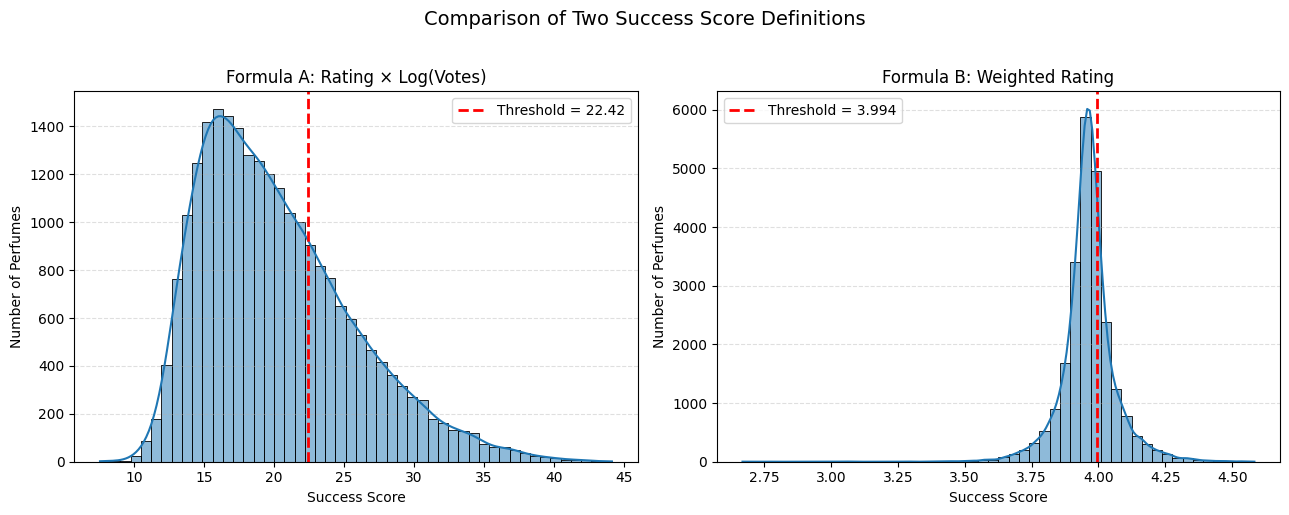

In [7]:
# Compare two success definitions

# Formula A — rating + popularity
df["success_score_A"] = df["rating_value"] * df["log_rating_count"]

# Formula B — weighted rating only
df["success_score_B"] = df["weighted_rating"]

# Create binary labels (top 30%)
thr_A = df["success_score_A"].quantile(0.70)
thr_B = df["success_score_B"].quantile(0.70)

df["success_A"] = (df["success_score_A"] >= thr_A).astype(int)
df["success_B"] = (df["success_score_B"] >= thr_B).astype(int)

# Quick comparison
print("Success rate A:", round(df["success_A"].mean(), 3))
print("Success rate B:", round(df["success_B"].mean(), 3))

agreement = (df["success_A"] == df["success_B"]).mean()
print("Agreement:", round(agreement, 3))

# Where they differ
diff = df[df["success_A"] != df["success_B"]]
percentage = round((len(diff) / len(df)) * 100, 1)

print("\nDisagreements:", len(diff), f"({percentage}% of dataset)")
print("\nDisagreements:", len(diff))

display(
    diff[[
        "perfume",
        "brand",
        "rating_value",
        "rating_count",
        "weighted_rating",
        "success_A",
        "success_B"
    ]].head(10)
)

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

sns.histplot(df["success_score_A"], bins=50, kde=True, ax=axes[0], edgecolor="black")
axes[0].axvline(thr_A, color="red", linestyle="--", linewidth=2, label=f"Threshold = {thr_A:.2f}")
axes[0].set_title("Formula A: Rating × Log(Votes)")
axes[0].set_xlabel("Success Score")
axes[0].set_ylabel("Number of Perfumes")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

sns.histplot(df["success_score_B"], bins=50, kde=True, ax=axes[1], edgecolor="black")
axes[1].axvline(thr_B, color="red", linestyle="--", linewidth=2, label=f"Threshold = {thr_B:.3f}")
axes[1].set_title("Formula B: Weighted Rating")
axes[1].set_xlabel("Success Score")
axes[1].set_ylabel("Number of Perfumes")
axes[1].legend()
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Comparison of Two Success Score Definitions", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "success_formula_comparison_kde.png", dpi=300, bbox_inches="tight")
plt.show()

## Conclusion

Both formulas were tested and compared.

- Formula A favors perfumes that are both well-rated AND popular
  → better represents commercial success
  
- Formula B favors high-rated perfumes regardless of popularity
  → better represents quality, even for niche perfumes

They disagree on 6,436 perfumes (27.0% of the dataset) — mainly 
high-rated but low-vote perfumes that Formula A penalizes 
for lack of reach.

**Final choice: Formula A**

Reason: commercial success in the fragrance industry requires 
both critical acclaim (rating) and market reach (votes). 
A perfume rated 4.8 by 10 people has not succeeded commercially.

Formula B is retained for niche quality analysis in the 
explainability notebook.



In [8]:
# Target variable creation

df[rating_col] = pd.to_numeric(df[rating_col], errors="coerce")
df[count_col] = pd.to_numeric(df[count_col], errors="coerce")
df[log_count_col] = pd.to_numeric(df[log_count_col], errors="coerce")

before_rows = len(df)
df = df.dropna(subset=[rating_col, log_count_col]).copy()
after_rows = len(df)

print(f"Dropped {before_rows - after_rows} rows due to missing target inputs")

# Success score
df["success_score"] = df[rating_col] * df[log_count_col]

# Top 30% as successful
threshold = df["success_score"].quantile(0.70)
df["success"] = (df["success_score"] >= threshold).astype(int)

print("Success threshold:", round(threshold, 4))
print(df["success"].value_counts(normalize=True).rename("proportion"))

display(df[[rating_col, count_col, log_count_col, "success_score", "success"]].head())


Dropped 0 rows due to missing target inputs
Success threshold: 22.4229
success
0    0.699992
1    0.300008
Name: proportion, dtype: float64


,rating_value,rating_count,log_rating_count,success_score,success
0,3.77,96,4.574711,17.246660,0
1,3.96,107,4.682131,18.541240,0
2,3.62,109,4.700480,17.015739,0
3,3.68,148,5.003946,18.414522,0
4,4.25,91,4.521789,19.217601,0


In [9]:
# Target leakage prention: Drop target-derived columns and unique identifiers

target_leakage_cols = [
    "success",
    "success_score",
    "rating_value",
    "rating_count",
    "weighted_rating",
    "log_rating_count",
    "popularity_class",
    "brand_mean_rating",
    "brand_mean_weighted_rating",
    "brand_mean_log_votes",
]

identifier_cols = [
    "url",
    "perfume",
    "brand",
    "country",
    "country_top",
    "gender",
]

redundant_cols = [
    "year",   # keep perfume_age instead
]

drop_from_features = sorted(set(target_leakage_cols + identifier_cols + redundant_cols))
existing_drop_cols = [c for c in drop_from_features if c in df.columns]

print("Columns excluded from modeling:")
print(existing_drop_cols)
print("Count:", len(existing_drop_cols))


Columns excluded from modeling:
['brand', 'brand_mean_log_votes', 'brand_mean_rating', 'brand_mean_weighted_rating', 'country', 'country_top', 'gender', 'log_rating_count', 'perfume', 'popularity_class', 'rating_count', 'rating_value', 'success', 'success_score', 'url', 'weighted_rating', 'year']
Count: 17


In [10]:
# Dynamic Feature Grouping (With Brand Fix)

all_cols = df.columns.tolist()

note_cols = [c for c in all_cols if c.startswith("note__")]
accord_cols = [c for c in all_cols if c.startswith("accord__")]
gender_ohe_cols = [c for c in all_cols if c.startswith("gender_")]
country_ohe_cols = [c for c in all_cols if c.startswith("country_")]

# Added Brand OHE capturing to fulfill scope requirements
brand_ohe_cols = [
    c for c in all_cols
    if c.startswith("brand_")
    and c not in target_leakage_cols + identifier_cols + ["brand_len", "brand_perfume_count"]
]

# Remove raw columns accidentally captured
gender_ohe_cols = [c for c in gender_ohe_cols if c != "gender"]
country_ohe_cols = [c for c in country_ohe_cols if c not in ["country", "country_top"]]

basic_numeric_cols = [
    c for c in [
        "perfume_age",
        "brand_len",
        "perfume_name_len",
        "top_note_count",
        "middle_note_count",
        "base_note_count",
        "note_count_total",
        "brand_perfume_count",
    ]
    if c in df.columns
]

print("note_cols:", len(note_cols))
print("accord_cols:", len(accord_cols))
print("gender_ohe_cols:", len(gender_ohe_cols))
print("country_ohe_cols:", len(country_ohe_cols))
print("brand_ohe_cols:", len(brand_ohe_cols))
print("basic_numeric_cols:", basic_numeric_cols)


note_cols: 300
accord_cols: 30
gender_ohe_cols: 4
country_ohe_cols: 25
brand_ohe_cols: 0
basic_numeric_cols: ['perfume_age', 'brand_len', 'perfume_name_len', 'top_note_count', 'middle_note_count', 'base_note_count', 'note_count_total', 'brand_perfume_count']


In [11]:
# Assemble final feature sets for two models

# Model 1: composition-only
composition_cols = sorted(set(
    note_cols +
    accord_cols +
    gender_ohe_cols +
    [c for c in basic_numeric_cols if c not in ["brand_perfume_count", "brand_len"]]
))

# Model 2: full model
full_cols = sorted(set(
    composition_cols +
    country_ohe_cols +
    brand_ohe_cols +
    [c for c in basic_numeric_cols]
))

# Final cleanup to ensure no leakage columns sneaked in
composition_cols = [c for c in composition_cols if c not in existing_drop_cols]
full_cols = [c for c in full_cols if c not in existing_drop_cols]

print("Composition feature count:", len(composition_cols))
print("Full feature count:", len(full_cols))


Composition feature count: 340
Full feature count: 367


In [12]:
# Leakage verification check

composition_leak_overlap = sorted(set(composition_cols).intersection(existing_drop_cols))
full_leak_overlap = sorted(set(full_cols).intersection(existing_drop_cols))

print("Composition overlap with dropped columns:", composition_leak_overlap)
print("Full overlap with dropped columns:", full_leak_overlap)


Composition overlap with dropped columns: []
Full overlap with dropped columns: []


In [13]:
# Missing value audit

for colset_name, colset in [("composition", composition_cols), ("full", full_cols)]:
    missing_summary = df[colset].isna().sum()
    missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

    print(f"\nMissing columns in {colset_name} model:", len(missing_summary))
    if len(missing_summary) > 0:
        display(missing_summary.head(20))



Missing columns in composition model: 1


perfume_age    2015
dtype: int64


Missing columns in full model: 1


perfume_age    2015
dtype: int64

In [14]:
# Fill missing values

#  1. Handle perfume_age separately
if "perfume_age" in df.columns:
    median_age = df["perfume_age"].median()
    df["perfume_age"] = df["perfume_age"].fillna(median_age)

# 2. Fill remaining features EXCLUDING perfume_age
composition_cols_wo_age = [c for c in composition_cols if c != "perfume_age"]
full_cols_wo_age = [c for c in full_cols if c != "perfume_age"]

df[composition_cols_wo_age] = df[composition_cols_wo_age].fillna(0)
df[full_cols_wo_age] = df[full_cols_wo_age].fillna(0)

print("Remaining missing in composition set:", int(df[composition_cols].isna().sum().sum()))
print("Remaining missing in full set:", int(df[full_cols].isna().sum().sum()))


Remaining missing in composition set: 0
Remaining missing in full set: 0


In [15]:
# Creating CSR matrix for model training

X_model1 = csr_matrix(df[composition_cols].astype(float).values)
X_model2 = csr_matrix(df[full_cols].astype(float).values)
y = df["success"].astype(int).values

print("X_model1 shape:", X_model1.shape)
print("X_model2 shape:", X_model2.shape)
print("y shape:", y.shape)


X_model1 shape: (23846, 340)
X_model2 shape: (23846, 367)
y shape: (23846,)


In [16]:
# Split data into 80% training and 20% testing

indices = np.arange(len(df))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X1_train = X_model1[train_idx]
X1_test = X_model1[test_idx]

X2_train = X_model2[train_idx]
X2_test = X_model2[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

print("Train size:", len(train_idx))
print("Test size:", len(test_idx))

print("\nTrain class distribution:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

print("\nTest class distribution:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index())


Train size: 19076
Test size: 4770

Train class distribution:
0    0.69999
1    0.30001
Name: proportion, dtype: float64

Test class distribution:
0    0.7
1    0.3
Name: proportion, dtype: float64


In [17]:
# Define helper functions which can be reused for both models

def evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }

    print(f"\n=== {model_name} ===")
    print(pd.Series(metrics))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    return model, metrics, y_pred, cm


def plot_confusion_matrix(cm, title, save_path):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def get_feature_importance_df(model, feature_names):
    fi_df = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)
    return fi_df


def plot_top_importances(fi_df, title, save_path, top_n=25):
    top_df = fi_df.head(top_n).copy()
    plt.figure(figsize=(8, 7))
    sns.barplot(data=top_df, x="importance", y="feature")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


In [18]:
# Create and train the first Random Forest model (composition only)

rf_model1 = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model1, metrics_model1, y_pred_1, cm1 = evaluate_classifier(
    rf_model1,
    X1_train, X1_test,
    y_train, y_test,
    model_name="RandomForest_CompositionOnly"
)



=== RandomForest_CompositionOnly ===
model        RandomForest_CompositionOnly
accuracy                           0.7174
precision                        0.563748
recall                           0.256464
f1                               0.352546
dtype: object

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.91      0.82      3339
           1       0.56      0.26      0.35      1431

    accuracy                           0.72      4770
   macro avg       0.65      0.59      0.59      4770
weighted avg       0.69      0.72      0.68      4770



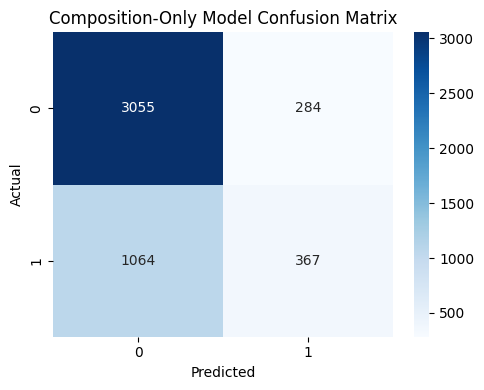

In [19]:
# Plot confusion matrix for composition only model

plot_confusion_matrix(
    cm1,
    title="Composition-Only Model Confusion Matrix",
    save_path=FIGURES_DIR / "rf_composition_confusion_matrix.png"
)


In [20]:
# Create and train the Second Random Forest model (Full Model)

rf_model2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model2, metrics_model2, y_pred_2, cm2 = evaluate_classifier(
    rf_model2,
    X2_train, X2_test,
    y_train, y_test,
    model_name="RandomForest_FullModel"
)



=== RandomForest_FullModel ===
model        RandomForest_FullModel
accuracy                   0.749266
precision                  0.617149
recall                     0.432565
f1                         0.508628
dtype: object

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.88      0.83      3339
           1       0.62      0.43      0.51      1431

    accuracy                           0.75      4770
   macro avg       0.70      0.66      0.67      4770
weighted avg       0.73      0.75      0.73      4770



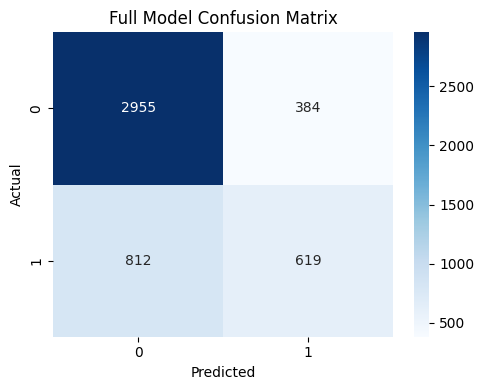

In [21]:
# Plot confusion matrix for full model

plot_confusion_matrix(
    cm2,
    title="Full Model Confusion Matrix",
    save_path=FIGURES_DIR / "rf_full_confusion_matrix.png"
)


## Model Results — Interpretation

Two models were compared:

- **Composition model:** uses note features, accord features, gender features, and fragrance structure features such as note counts and perfume age  
- **Full model:** adds country features, brand features, and brand-related numeric variables such as `brand_perfume_count` and `brand_len`

### Key observations

- The **composition model** performs poorly in detecting successful perfumes  
  - recall = 0.26  
  - it misses many successful cases  

- The **full model** performs noticeably better  
  - recall increases to 0.43  
  - F1 score also improves  

### Insight

This shows that **notes and accords alone are not enough to explain success**.

The improvement in the full model suggests that success is influenced not only by fragrance composition, but also by factors such as:

- **brand identity**
- **brand scale** (`brand_perfume_count`)
- **country / origin features**
- **other basic product-level characteristics**

### Conclusion

Fragrance composition contributes to success, but it is **not sufficient on its own**.

The better performance of the full model suggests that external brand and market-related factors play an important role in determining whether a fragrance becomes successful.


## Threshold Tuning

The default model uses a threshold of 0.5 to classify a perfume as successful.

However, this makes the model conservative and results in low recall, meaning many successful perfumes are missed.

To improve this, the threshold is lowered so the model predicts more perfumes as successful.


In [22]:
# Threshold tuning to increase recall

y_prob_full = rf_model2.predict_proba(X2_test)[:, 1]

# lower threshold to capture more positives
tuning_threshold = 0.39
y_pred_tuned = (y_prob_full >= tuning_threshold).astype(int)

metrics_tuned = {
    "model": "RandomForest_FullModel (tuned)",
    "accuracy": accuracy_score(y_test, y_pred_tuned),
    "precision": precision_score(y_test, y_pred_tuned, zero_division=0),
    "recall": recall_score(y_test, y_pred_tuned, zero_division=0),
    "f1": f1_score(y_test, y_pred_tuned, zero_division=0),
}

print("\n=== RandomForest_FullModel (tuned threshold) ===")
print(pd.Series(metrics_tuned))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, zero_division=0))




=== RandomForest_FullModel (tuned threshold) ===
model        RandomForest_FullModel (tuned)
accuracy                           0.706709
precision                          0.507921
recall                             0.716981
f1                                  0.59461
dtype: object

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.70      0.77      3339
           1       0.51      0.72      0.59      1431

    accuracy                           0.71      4770
   macro avg       0.68      0.71      0.68      4770
weighted avg       0.75      0.71      0.72      4770



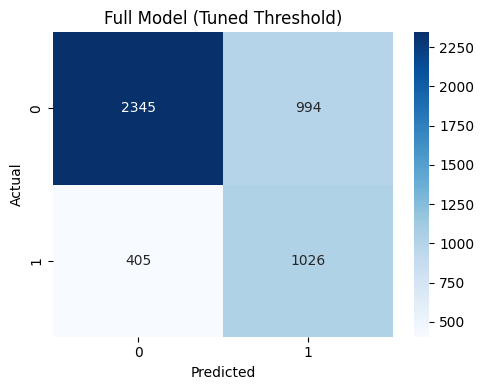

In [23]:
# Plot confusion matrix for full tuned model

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plot_confusion_matrix(
    cm_tuned,
    title="Full Model (Tuned Threshold)",
    save_path=FIGURES_DIR / "rf_full_tuned_confusion_matrix.png"
)


## Results After Tuning

Lowering the threshold from 0.5 to 0.39 improved the model’s ability to detect successful perfumes.

- Recall improved significantly (**0.43 → 0.72**), meaning the model now captures most successful perfumes  
- F1-score improved (**0.51 → 0.59**), indicating a better balance overall  
- Precision decreased (**0.62 → 0.51**), showing an increase in false positives  
- Accuracy dropped slightly (**0.75 → 0.71**), which is expected  

### Conclusion

The tuned model is more effective for this task, as it prioritizes identifying successful perfumes.  

The trade-off in precision and accuracy is acceptable because missing successful perfumes is more costly than predicting some false positives.


In [24]:
# Save trained models

joblib.dump(rf_model1, MODELS_DIR / "rf_composition.pkl")
joblib.dump(rf_model2, MODELS_DIR / "rf_full.pkl")

# Save threshold configuration (for tuned model behavior)
model_config = {
    "rf_full_threshold": 0.39
}

with open(MODELS_DIR / "model_config.json", "w") as f:
    json.dump(model_config, f, indent=2)

# Confirm
print("Saved models:")
print("-", MODELS_DIR / "rf_composition.pkl")
print("-", MODELS_DIR / "rf_full.pkl")
print("-", MODELS_DIR / "model_config.json")

Saved models:
- ..\models\rf_composition.pkl
- ..\models\rf_full.pkl
- ..\models\model_config.json


In [25]:
# Export Metrics Comparison

results_df = pd.DataFrame([
    metrics_model1,
    metrics_model2,
    metrics_tuned
]).sort_values("f1", ascending=False)

display(results_df)

results_df.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)
print("Saved:", RESULTS_DIR / "model_comparison.csv")


,model,accuracy,precision,recall,f1
2,RandomForest_FullModel (tuned),0.706709,0.507921,0.716981,0.594610
1,RandomForest_FullModel,0.749266,0.617149,0.432565,0.508628
0,RandomForest_CompositionOnly,0.717400,0.563748,0.256464,0.352546


Saved: ..\reports\results\model_comparison.csv


In [26]:
# Feature Importances Display

fi_model1 = get_feature_importance_df(rf_model1, composition_cols)
fi_model2 = get_feature_importance_df(rf_model2, full_cols)

print("Top features — Composition model")
display(fi_model1.head(25))

print("Top features — Full model")
display(fi_model2.head(25))


Top features — Composition model


,feature,importance
337,perfume_age,0.088063
338,perfume_name_len,0.055052
336,note_count_total,0.040304
30,base_note_count,0.028916
35,middle_note_count,0.026959
339,top_note_count,0.025548
204,note__musk,0.011210
24,accord__vanilla,0.011125
28,accord__woody,0.010838
266,note__sandalwood,0.010477


Top features — Full model


,feature,importance
32,brand_perfume_count,0.110203
364,perfume_age,0.067645
365,perfume_name_len,0.044421
31,brand_len,0.044036
363,note_count_total,0.032350
30,base_note_count,0.024332
62,middle_note_count,0.020852
366,top_note_count,0.020290
38,country_France,0.018031
231,note__musk,0.009441


In [27]:
# Export Feature Importances

fi_model1.to_csv(RESULTS_DIR / "rf_composition_feature_importance.csv", index=False)
fi_model2.to_csv(RESULTS_DIR / "rf_full_feature_importance.csv", index=False)

print("Saved composition feature importance CSV")
print("Saved full feature importance CSV")


Saved composition feature importance CSV
Saved full feature importance CSV


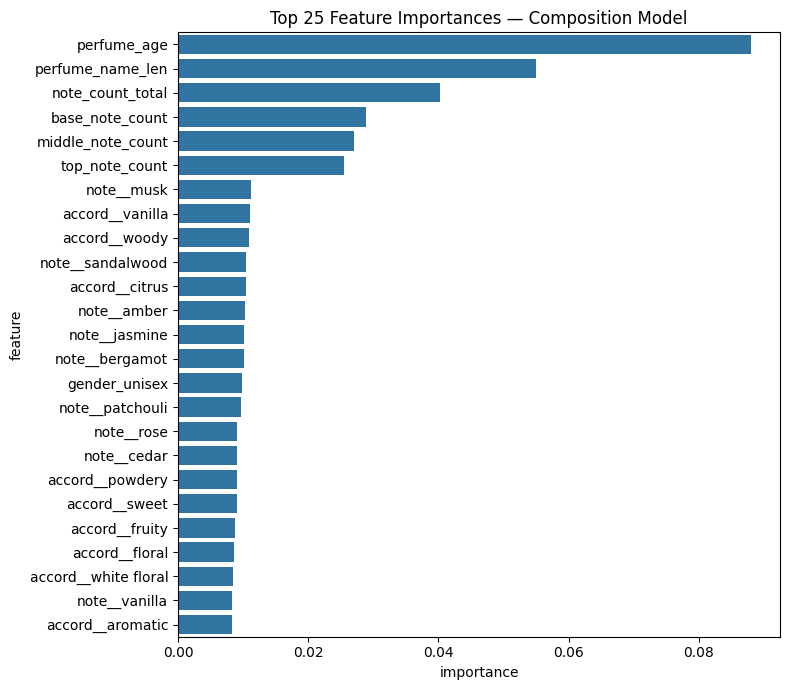

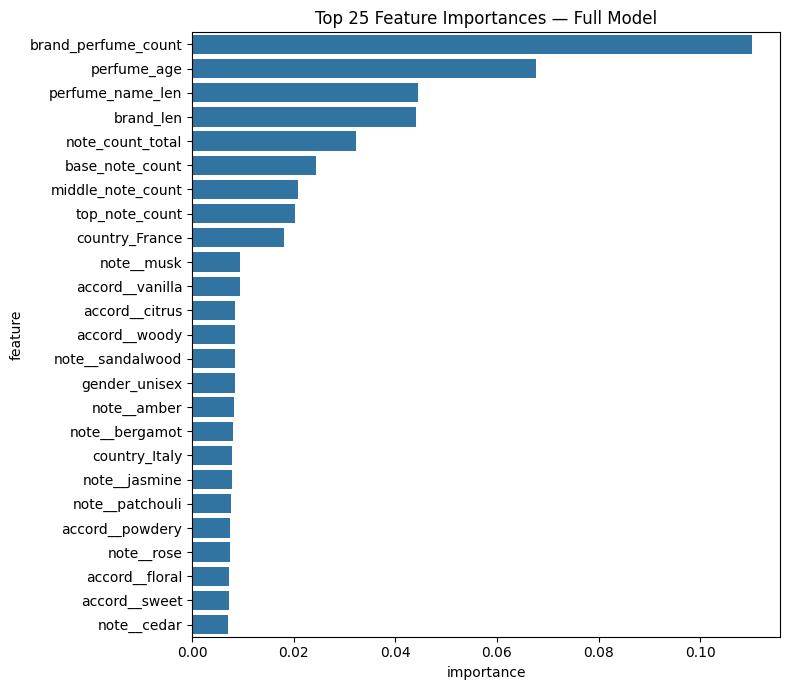

In [28]:
# Plot top importances 

plot_top_importances(
    fi_model1,
    title="Top 25 Feature Importances — Composition Model",
    save_path=FIGURES_DIR / "rf_composition_top25_importance.png",
    top_n=25
)

plot_top_importances(
    fi_model2,
    title="Top 25 Feature Importances — Full Model",
    save_path=FIGURES_DIR / "rf_full_top25_importance.png",
    top_n=25
)


In [29]:
# Save predictions

keep_for_output = [
    c for c in [
        "perfume", "brand",
        rating_col, count_col,
        "success", "success_score"
    ]
    if c in df.columns
]

test_results = df.iloc[test_idx][keep_for_output].copy()
test_results["pred_composition"] = y_pred_1
test_results["pred_full"] = y_pred_2
test_results["pred_full_tuned"] = y_pred_tuned

test_results.to_csv(RESULTS_DIR / "test_predictions.csv", index=False)
display(test_results.head())
print("Saved:", RESULTS_DIR / "test_predictions.csv")


,perfume,brand,rating_value,rating_count,success,success_score,pred_composition,pred_full,pred_full_tuned
8316,gracefl,faberlic,3.33,33,0,11.742781,0,0,0
17085,les-monstres-de-nina-ricci-nina,nina-ricci,3.91,188,0,20.495231,0,0,1
8421,fan-di-fendi-pour-homme-acqua,fendi,3.94,454,1,24.113972,0,0,0
13157,la-perla-signature,la-perla,4.15,189,0,21.775150,0,0,0
15978,vanille-fruitee,molinard,3.85,127,0,18.680317,1,1,1


Saved: ..\reports\results\test_predictions.csv


In [30]:
# Export artifacts for SHAP notebook

artifacts = {
    "success_threshold": float(df["success_score"].quantile(0.70)),
    "tuning_threshold": float(tuning_threshold),
    "composition_cols": composition_cols,
    "full_cols": full_cols,
    "train_idx": train_idx.tolist(),
    "test_idx": test_idx.tolist(),
    "dropped_feature_cols": existing_drop_cols,
}

with open(RESULTS_DIR / "modeling_artifacts.json", "w", encoding="utf-8") as f:
    json.dump(artifacts, f, indent=2)

print("Saved:", RESULTS_DIR / "modeling_artifacts.json")



Saved: ..\reports\results\modeling_artifacts.json
